In [ ]:
#3
import numpy as np
from numpy import array #change np to numpy
from numpy.linalg import inv as inv

a1 = [ 5 , 8 , 13, 'tree']
a1
a2 = array( [ 5 , 8 , 13 ] )
a2
a = array([[ 5 , 8 , 13 ]])
a
#b1 = a1.T
#b2 = a2.T
#b2
b = a.T
b
c1 = a1 * 2
c1
c2 = a2 * 2
c2
c = a * 2
c
#x = array([9, 8, 7])*array(11) not necessary
#x = array([9, 8, 7])*11
#x
#x = b ˆ 3
#x = b^3
#x
d = b**3
d
p1 = a * b
p1
p2 = a * b.T
p2
p4 = a @ b
p4
#p5 = a @ b.T
#p5
#p6 = a.T @ b
#p6
q1 = a / b
q1
#q2 = a \ b
#q2
A1 = [ b , b+21 , b**2 ]
A1
#A2 = array( b , b+21 , b**2 )\
A = np.vstack([ a, a+21, a**2 ])
A
x = inv (A) @ b
x
z = A @ x- b
AtA = A.T @ A
AtA
B = np.hstack([ b , b**2 ])
B
u = np.arange(0, 10)
u
v=  u[9]
v
# Mistake: trying to access an index that doesn't exist
v = u[10]      # !! IndexError if u has fewer than 11 elements
# Fix:

v = u[10]     #??. IndexError if u has fewer than 11 elements
v = u[-100]   #??. IndexError if array is not that long
v = A[3]      #??. This returns the whole row, not a single element
v = A[:,3:1]  #??. Empty slice because the stop < start
# Mistake: ambiguous row/element indexing
v = A[3]       # ?? returns the 4th row, not a single element
# Fix:
v = A[3,:]     # ok. explicitly get row 3

# Mistake: backward slicing creates empty result
v = A[:,3:1]   # ?? empty slice, since stop < start
# Fix:
v = A[:,1:3]   # ok. proper increasing slice for columns 1 and 2



np.int64(9)

In [ ]:
# rankA.py
# 4

import numpy as np

# Choose dimensions
m = 2  # number of rows of A
n = 5  # number of columns of A

# Random m x n matrix
A = np.random.randn(m, n)

# Compute A^T A and A A^T
AtA = A.T @ A
AAt = A @ A.T

# Sizes and ranks
sizeA = A.shape
rankA = np.linalg.matrix_rank(A)

sizeAtA = AtA.shape
rankAtA = np.linalg.matrix_rank(AtA)

sizeAAt = AAt.shape
rankAAt = np.linalg.matrix_rank(AAt)

# Print results
print("size(A)   =", sizeA)
print("rank(A)   =", rankA)
print("size(AtA) =", sizeAtA)
print("rank(AtA) =", rankAtA)
print("size(AAt) =", sizeAAt)
print("rank(AAt) =", rankAAt)


size(A)   = (2, 5)
rank(A)   = 2
size(AtA) = (5, 5)
rank(AtA) = 2
size(AAt) = (2, 2)
rank(AAt) = 2


In [ ]:
# finite_precision.py
# 5

import numpy as np

np.set_printoptions(precision=20)

# Example (a) -----------------------------------------------------------
sp = np.sin(np.pi / 2)
error = sp - 1
print("Example (a):")
print("sin(pi/2):", sp)
print("error:", error)
print("Explanation: error is not exactly zero because pi cannot be represented exactly in floating point.\n")

# Example (b) -----------------------------------------------------------
def run_experiment(iterations=100000):
    err_gr = 0.0
    err_05 = 0.0
    err_08 = 0.0
    err_11 = 0.0
    err_20 = 0.0
    err_22 = 0.0
    err_32 = 0.0
    err_35 = 0.0

    gr = (np.sqrt(5) - 1.0) / 2.0
    for x in range(iterations):
        err_gr += abs(x - (1.0/gr) * x * gr)
        err_05 += abs(x - (1.0/5.0) * x * 5.0)
        err_08 += abs(x - (1.0/8.0) * x * 8.0)
        err_11 += abs(x - (1.0/11.0) * x * 11.0)
        err_20 += abs(x - (1.0/20.0) * x * 20.0)
        err_22 += abs(x - (1.0/22.0) * x * 22.0)
        err_32 += abs(x - (1.0/32.0) * x * 32.0)
        err_35 += abs(x - (1.0/35.0) * x * 35.0)

    print(f"Results with {iterations} iterations:")
    print(" err_gr:", err_gr)
    print(" err_05:", err_05)
    print(" err_08:", err_08, "<-- exactly 0 (power of 2)")
    print(" err_11:", err_11)
    print(" err_20:", err_20)
    print(" err_22:", err_22)
    print(" err_32:", err_32, "<-- exactly 0 (power of 2)")
    print(" err_35:", err_35)
    print()

# Run with 100,000 iterations
run_experiment(100000)

# Run with 100 iterations
run_experiment(100)

# Explanation section
print("=== Explanation ===")
print("1. Errors accumulate because floating-point arithmetic is not exact.")
print("2. Numbers 8 and 32 are powers of 2, so they are represented exactly in binary,")
print("   making their errors vanish. Numbers like 5, 11, 20, 22, 35 are not exact in binary,")
print("   so rounding errors appear.")
print("3. With 100 iterations instead of 100,000, errors are about 1000 times smaller,")
print("   showing that error accumulates roughly linearly.")
print("4. An error of 1e-6 can be considered negligible when working with numbers of order 1,")
print("   since it represents accuracy up to six decimal places.")


Example (a):
sin(pi/2): 1.0
error: 0.0
Explanation: error is not exactly zero because pi cannot be represented exactly in floating point.

Results with 100000 iterations:
 err_gr: 1.0034440034445424e-07
 err_05: 1.3704605672515413e-07
 err_08: 0.0 <-- exactly 0 (power of 2)
 err_11: 7.896045595146006e-08
 err_20: 1.3704605672515413e-07
 err_22: 7.896045595146006e-08
 err_32: 0.0 <-- exactly 0 (power of 2)
 err_35: 1.4667781922383938e-07

Results with 100 iterations:
 err_gr: 1.056932319443149e-13
 err_05: 1.5498713423767185e-13
 err_08: 0.0 <-- exactly 0 (power of 2)
 err_11: 7.283063041541027e-14
 err_20: 1.5498713423767185e-13
 err_22: 7.283063041541027e-14
 err_32: 0.0 <-- exactly 0 (power of 2)
 err_35: 1.412203687323199e-13

=== Explanation ===
1. Errors accumulate because floating-point arithmetic is not exact.
2. Numbers 8 and 32 are powers of 2, so they are represented exactly in binary,
   making their errors vanish. Numbers like 5, 11, 20, 22, 35 are not exact in binary,
   s

In [ ]:
# rankA.py
# 5

import numpy as np

def show_ranks(A, name="A"):
    """Compute and print size and rank of A, A^T A, and A A^T."""
    AtA = A.T @ A
    AAt = A @ A.T
    rankA = np.linalg.matrix_rank(A)
    rankAtA = np.linalg.matrix_rank(AtA)
    rankAAt = np.linalg.matrix_rank(AAt)
    print(f"\n{name}: shape {A.shape}")
    print(" rank(A)   =", rankA)
    print(" shape(A^T A) =", AtA.shape, " rank(A^T A) =", rankAtA)
    print(" shape(A A^T) =", AAt.shape, " rank(A A^T) =", rankAAt)
    return rankA, rankAtA, rankAAt

def random_trials():
    """Run trials with different (m,n) including n=1."""
    rng = np.random.default_rng(0)
    trials = [(2, 5), (3, 1), (1, 5), (4, 4)]
    print("=== Random trials with different m,n ===")
    for m, n in trials:
        A = rng.standard_normal((m, n))
        show_ranks(A, name=f"Random A ({m}x{n})")

def explicit_m2_rank1_example():
    """Construct explicit m=2 example where rank(AA^T)=1."""
    v = np.array([1.0, 2.0, -0.5, 3.0])  # arbitrary row
    alpha = 2.5
    row1 = v
    row2 = alpha * v
    A = np.vstack([row1, row2])
    print("\n=== Explicit m=2 case where rank(AA^T)=1 ===")
    show_ranks(A, name="Dependent rows A (2x4)")
    print("Explanation: Here row2 = alpha * row1, so rows are linearly dependent.")
    print("Therefore, rank(A) = 1 and rank(AA^T) = 1.")

def explanation_text():
    """Prints conceptual explanation of the results (Q4 answer)."""
    print("\n=== Explanation of Results (Q4) ===")
    print("""
1. The rank of a matrix equals the number of linearly independent rows or columns.
   For random matrices with entries from a continuous distribution, rows/columns are
   almost always independent, so rank(A) = min(m,n).

2. When n=1 (single column):
   - If the column is zero → rank(A) = 0.
   - If the column is nonzero → rank(A) = 1.
   This makes sense because a single vector spans at most a 1D space.

3. The ranks of A, A^T A, and A A^T are always the same.
   Reason: A^T A and A A^T are Gram matrices with the same nonzero singular values as A.

4. Special case m=2:
   - rank(AA^T) = 1 occurs exactly when the two rows of A are linearly dependent
     (one row is a scalar multiple of the other).
   - Otherwise, if rows are independent, rank(A) = rank(AA^T) = 2.
""")

if __name__ == "__main__":
    random_trials()
    explicit_m2_rank1_example()
    explanation_text()


=== Random trials with different m,n ===

Random A (2x5): shape (2, 5)
 rank(A)   = 2
 shape(A^T A) = (5, 5)  rank(A^T A) = 2
 shape(A A^T) = (2, 2)  rank(A A^T) = 2

Random A (3x1): shape (3, 1)
 rank(A)   = 1
 shape(A^T A) = (1, 1)  rank(A^T A) = 1
 shape(A A^T) = (3, 3)  rank(A A^T) = 1

Random A (1x5): shape (1, 5)
 rank(A)   = 1
 shape(A^T A) = (5, 5)  rank(A^T A) = 1
 shape(A A^T) = (1, 1)  rank(A A^T) = 1

Random A (4x4): shape (4, 4)
 rank(A)   = 4
 shape(A^T A) = (4, 4)  rank(A^T A) = 4
 shape(A A^T) = (4, 4)  rank(A A^T) = 4

=== Explicit m=2 case where rank(AA^T)=1 ===

Dependent rows A (2x4): shape (2, 4)
 rank(A)   = 1
 shape(A^T A) = (4, 4)  rank(A^T A) = 1
 shape(A A^T) = (2, 2)  rank(A A^T) = 1
Explanation: Here row2 = alpha * row1, so rows are linearly dependent.
Therefore, rank(A) = 1 and rank(AA^T) = 1.

=== Explanation of Results (Q4) ===

1. The rank of a matrix equals the number of linearly independent rows or columns.
   For random matrices with entries from a co

Indices: [ 1  2  3  4  5  6  7  8  9 10]
Fibonacci: [ 1  1  2  3  5  8 13 21 34 55]


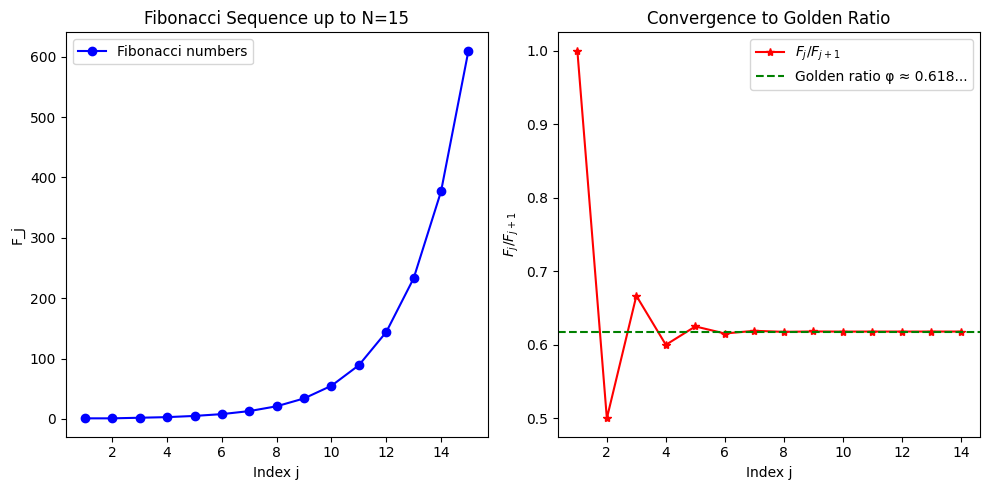

In [ ]:
# fibo.py
# 6

import numpy as np
import matplotlib.pyplot as plt

def fibno(N):
    """
    Returns:
      j : array of indices [1,...,N]
      F : array of Fibonacci numbers [F1,...,FN]
    """
    if N < 2:
        raise ValueError("N must be >= 2")

    F = np.zeros(N, dtype=int)
    F[0], F[1] = 1, 1
    for k in range(2, N):
        F[k] = F[k-1] + F[k-2]

    j = np.arange(1, N+1)
    return j, F


def fibno_plot(N):
    """
    Plots:
      - Fibonacci sequence values
      - Ratios F_j / F_{j+1} converging to golden ratio
    """
    j, F = fibno(N)
    ratios = F[:-1] / F[1:]

    plt.figure(figsize=(10,5))

    # Fibonacci sequence
    plt.subplot(1,2,1)
    plt.plot(j, F, 'bo-', label='Fibonacci numbers')
    plt.xlabel("Index j")
    plt.ylabel("F_j")
    plt.title(f"Fibonacci Sequence up to N={N}")
    plt.legend()

    # Ratio convergence
    plt.subplot(1,2,2)
    plt.plot(j[:-1], ratios, 'r*-', label=r"$F_j / F_{j+1}$")
    plt.axhline((np.sqrt(5)-1)/2, color='g', linestyle='--',
                label='Golden ratio φ ≈ 0.618...')
    plt.xlabel("Index j")
    plt.ylabel(r"$F_j / F_{j+1}$")
    plt.title("Convergence to Golden Ratio")
    plt.legend()

    plt.tight_layout()
    plt.show()


# ------------------------------
# Self-test code
# ------------------------------
if __name__ == "__main__":
    j, F = fibno(10)
    print("Indices:", j)
    print("Fibonacci:", F)

    fibno_plot(15)




In [ ]:
# Assignment 7
#sum_pi.py
# 7

import numpy as np
import matplotlib.pyplot as plt

def sum_series(N):
    """
    Computes the sum S(N) without using for-loops or sum().
    Uses vectorized operations and dot product (@).
    """
    j = np.arange(1, N+1)
    numerators = 4 * ((-1)**(j+1))
    denominators = 2*j - 1
    return numerators @ (1/denominators)

def sum_plot(Nmax):
    """
    Plots S(N) vs N using a for-loop approach.
    """
    S_values = []
    for N in range(1, Nmax+1):
        S_values.append(sum_series(N))

    N_range = np.arange(1, Nmax+1)
    plt.figure(figsize=(8, 5))
    plt.plot(N_range, S_values, marker='o', label="S(N)")
    plt.axhline(y=np.pi, color='r', linestyle='--', label="π")
    plt.title("Convergence of S(N) to π")
    plt.xlabel("N")
    plt.ylabel("S(N)")
    plt.legend()
    plt.grid()
    plt.show()


3.0418396189294032


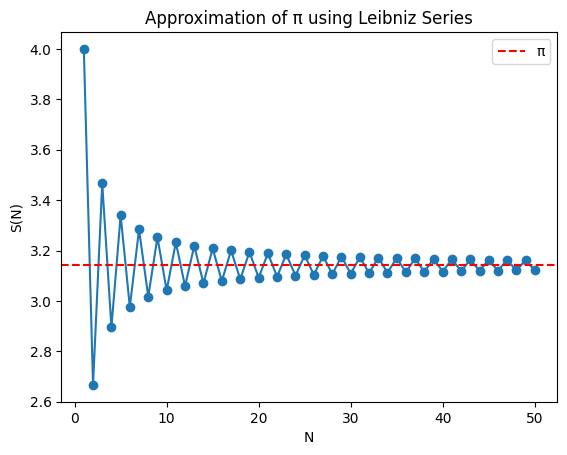

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sumseries(N):
    j = np.arange(1, N+1)
    return (4 / (2*j - 1)) @ ((-1)**(j+1)).T

def sumplot(N):
    S = []
    for n in range(1, N+1):
        s = 0
        for j in range(1, n+1):
            s += (4 / (2*j - 1)) * ((-1)**(j+1))
        S.append(s)
    plt.plot(range(1, N+1), S, marker='o')
    plt.axhline(np.pi, color='r', linestyle='--', label='π')
    plt.xlabel("N")
    plt.ylabel("S(N)")
    plt.title("Approximation of π using Leibniz Series")
    plt.legend()
    plt.show()

# Run them
print(sumseries(10))
sumplot(50)
